# Ordinal Data
Feature reduction, redundancy and feature engineering

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

data = pd.read_csv("Data/ordinal_train_cleaned.csv")
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X

,OverallQual,OverallQual.1,OverallCond,MSSubClass,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,...,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,LotShape,LandSlope,LandContour,SaleCondition
0,7,7,5,60,4,3,4,3,1,6,...,5,4,4,2,3,3,3,2,3,4
1,6,6,8,20,3,3,4,3,4,5,...,5,3,3,2,3,3,3,2,3,4
2,7,7,5,60,4,3,4,3,2,6,...,5,4,3,2,3,3,2,2,3,4
3,7,7,5,70,3,3,3,4,1,5,...,4,4,4,1,3,3,2,2,3,0
4,8,8,5,60,4,3,4,3,3,6,...,5,4,3,2,3,3,2,2,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,5,60,3,3,4,3,1,1,...,5,3,3,2,3,3,3,2,3,4
1408,6,6,6,20,3,3,4,3,1,5,...,3,3,3,1,3,3,3,2,3,4
1409,7,7,9,70,5,4,3,4,1,6,...,5,4,4,2,3,3,3,2,3,4
1410,5,5,6,20,3,3,3,3,2,6,...,4,4,4,1,3,3,3,2,3,4


# Mutual Information Score
as first feature reduction criterion

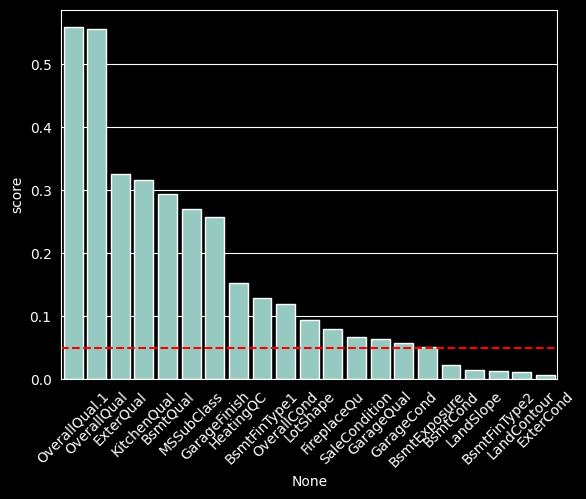

In [45]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

And We take those having MI score grater than 0.05

In [46]:
selected_X = X[mi_series[mi_series.values > 0.05].keys()]
removed_x = X[mi_series[mi_series.values < 0.05].keys()]

selected_X

,OverallQual.1,OverallQual,ExterQual,KitchenQual,BsmtQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,LotShape,FireplaceQu,SaleCondition,GarageQual,GarageCond,BsmtExposure
0,7,7,4,4,4,60,2,5,6,5,3,4,4,3,3,1
1,6,6,3,3,4,20,2,5,5,8,3,3,4,3,3,4
2,7,7,4,4,4,60,2,5,6,5,2,3,4,3,3,2
3,7,7,3,4,3,70,1,4,5,5,2,4,0,3,3,1
4,8,8,4,4,4,60,2,5,6,5,2,3,4,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,3,3,4,60,2,5,1,5,3,3,4,3,3,1
1408,6,6,3,3,4,20,1,3,5,6,3,3,4,3,3,1
1409,7,7,5,4,3,70,2,5,6,9,3,4,4,3,3,1
1410,5,5,3,4,3,20,1,4,6,6,3,4,4,3,3,2


# Vizualizations
with target

## Selected X
to check if categories are correlated with target

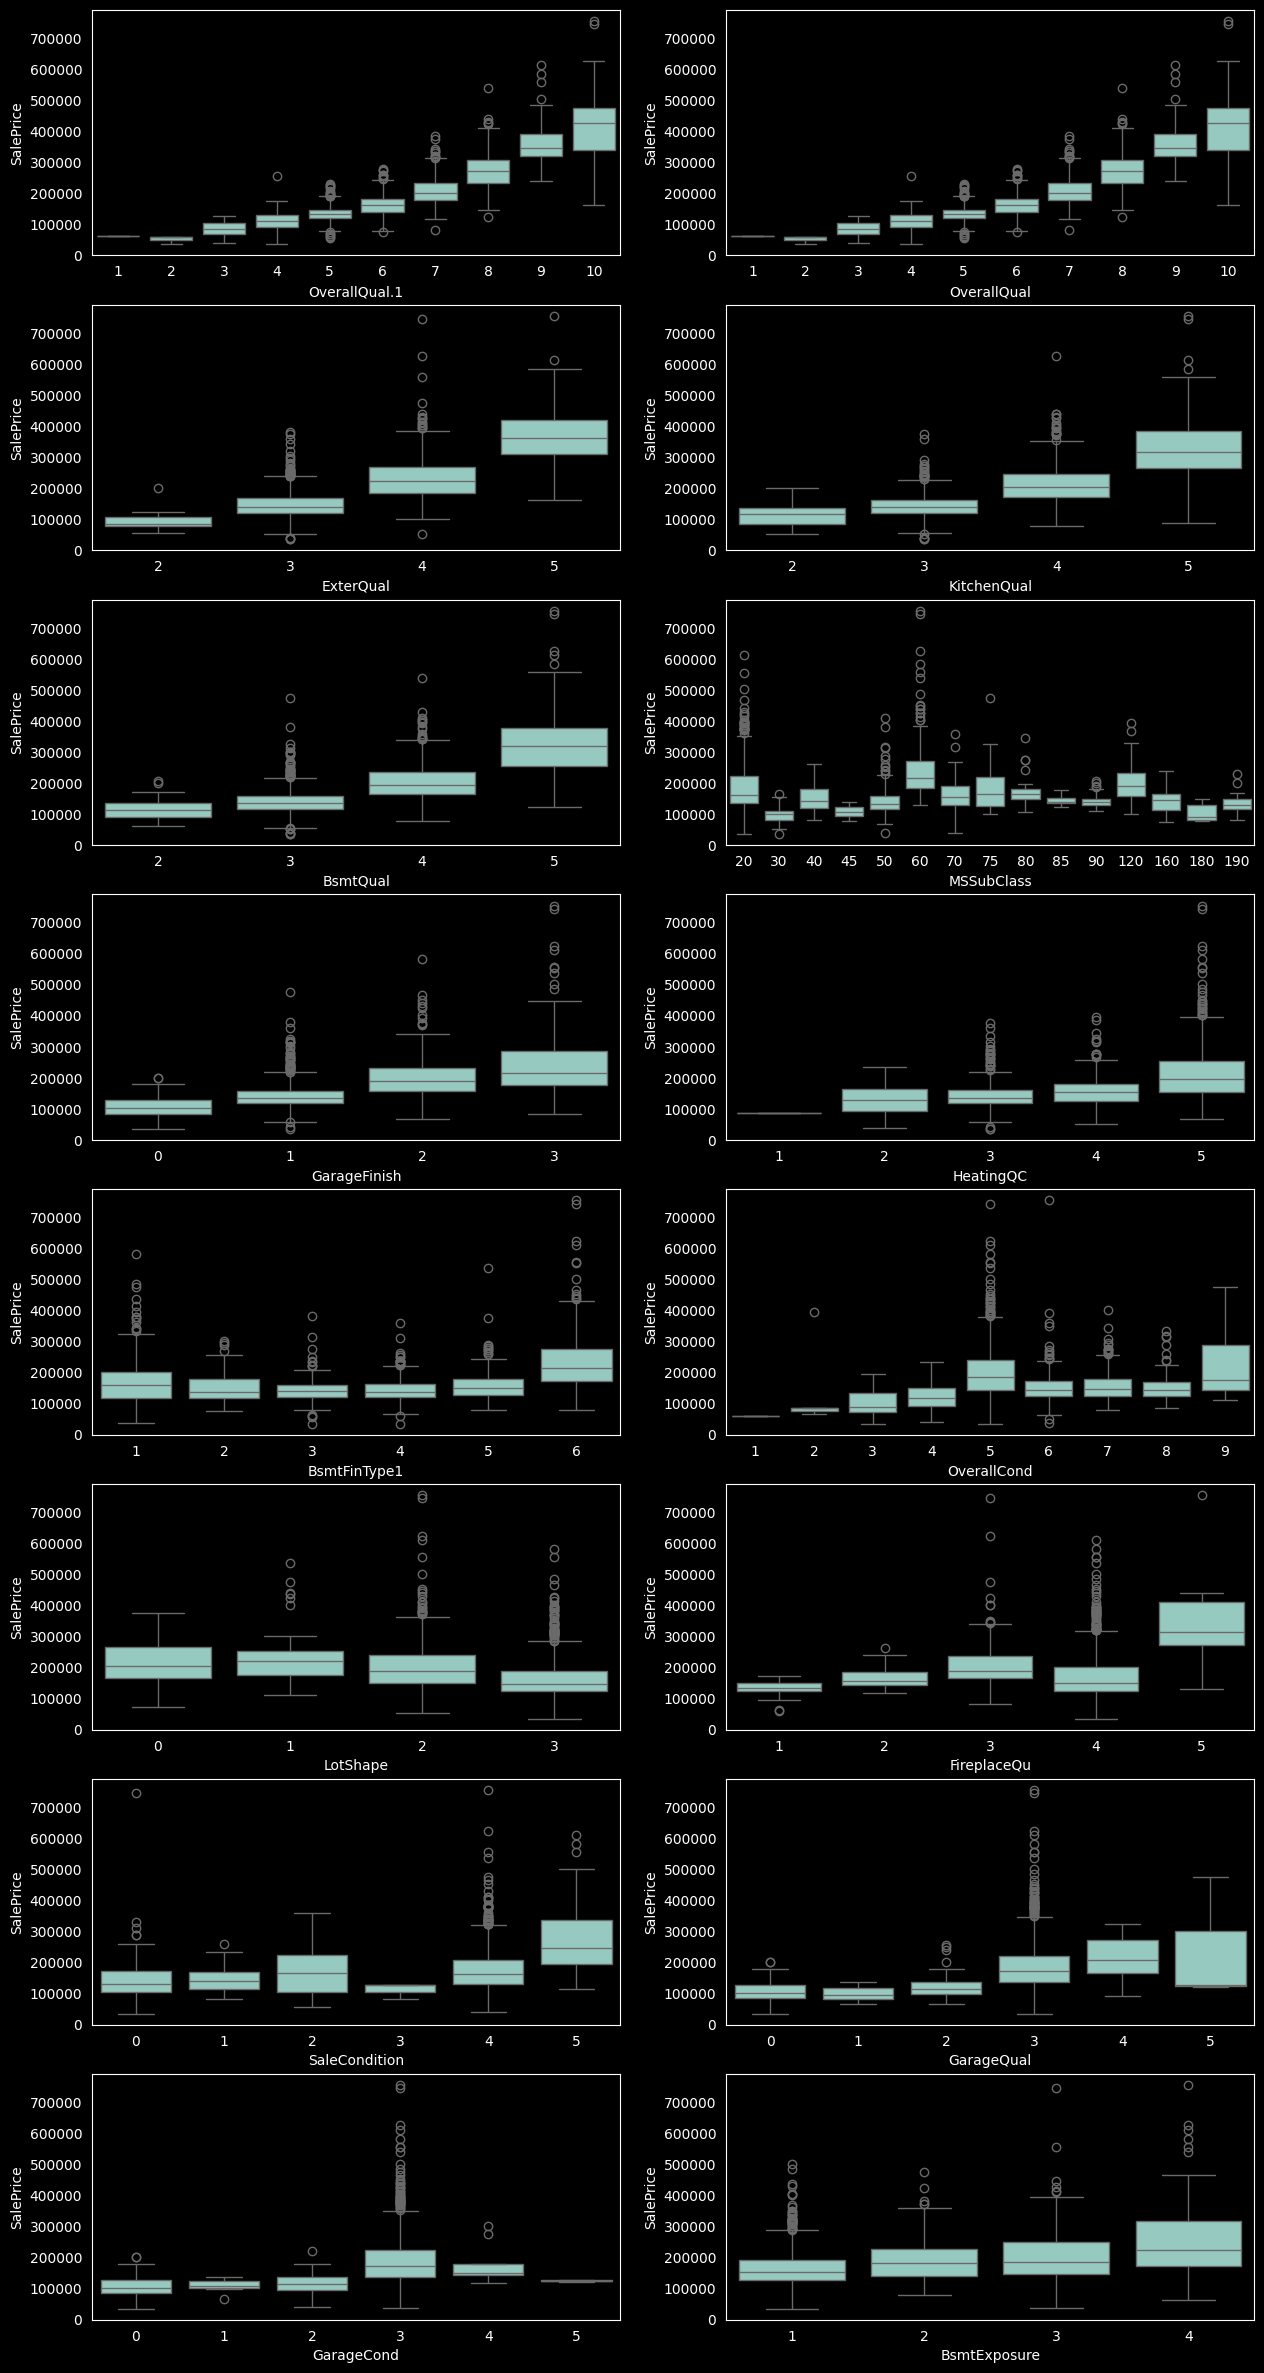

In [47]:
fig, ax = plt.subplots(8,2, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(selected_X.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Unselected X

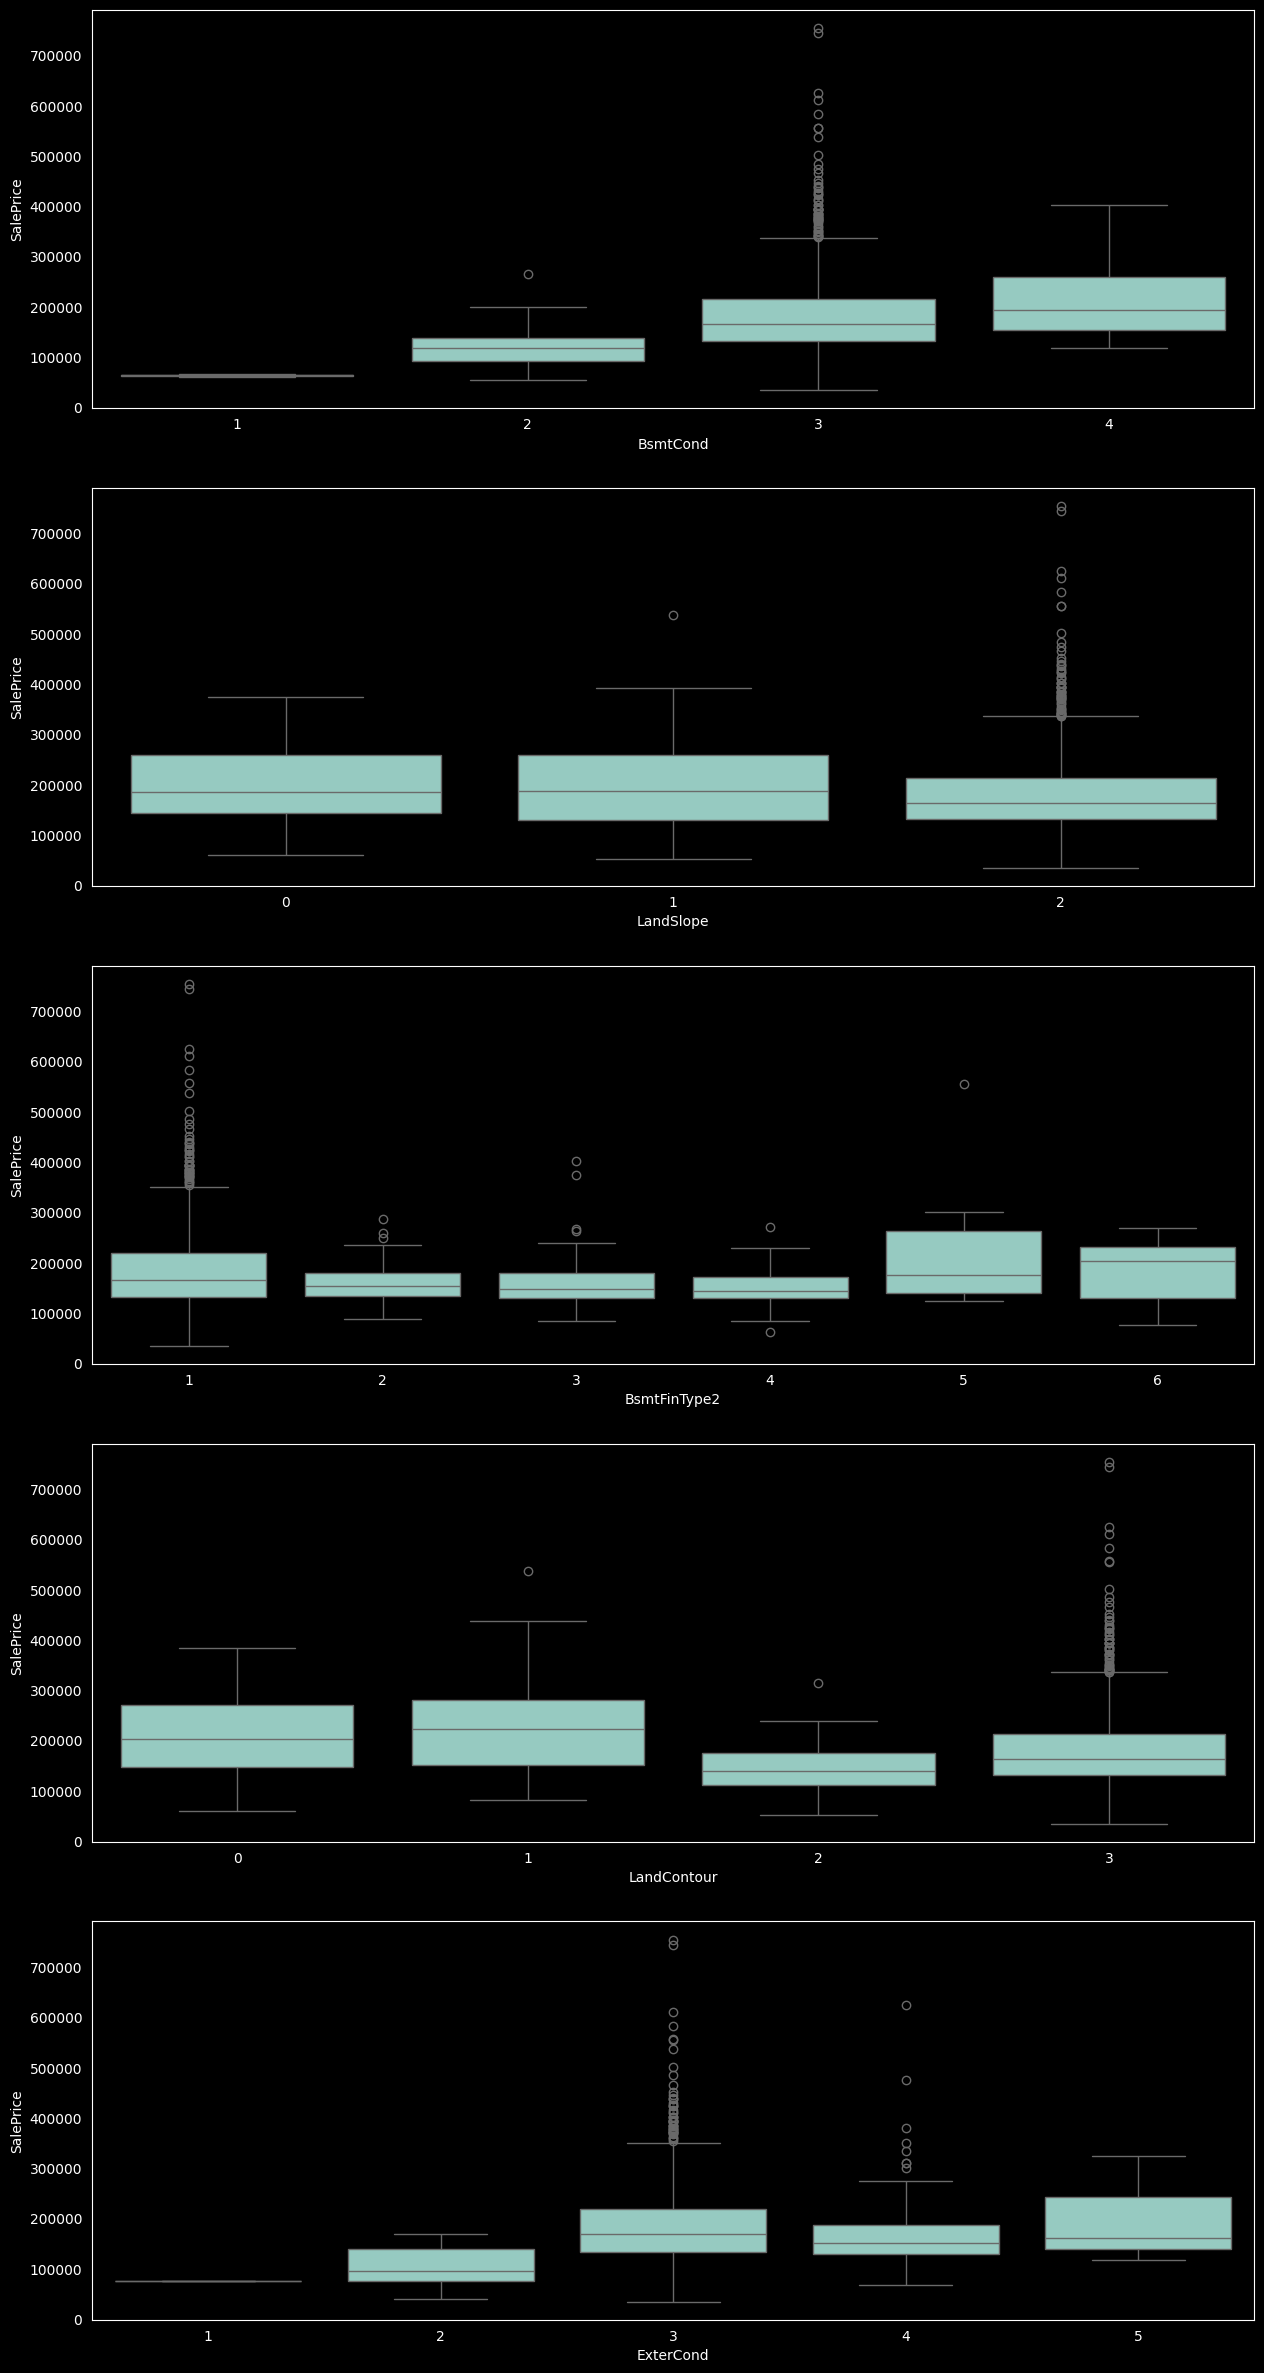

In [48]:
fig, ax = plt.subplots(5,1, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(removed_x.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Additional reduction
Basing on plots and analyzing correlation with target `BsmtQual` is removed. Rest stays the same.


In [49]:
new_X = selected_X.drop('BsmtQual', axis=1)

# PCA Analysis

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)

pca.fit(new_X)


df_components = pd.DataFrame()
pca.components_

array([[ 1.25264638e-03,  1.25264638e-03,  3.22845183e-04,
        -1.11086230e-04,  9.99991615e-01, -5.21984633e-04,
        -1.30010674e-04,  1.65245631e-03, -1.66136550e-03,
         1.57181028e-03, -1.44993978e-04, -6.33090504e-04,
        -9.94270150e-04, -1.31496976e-03,  1.45735895e-03],
       [ 4.61477261e-01,  4.61477261e-01,  1.64882376e-01,
         1.84063441e-01, -1.98876918e-03,  2.33356086e-01,
         1.91148763e-01,  5.85842350e-01, -6.66347243e-02,
        -5.82066553e-02, -4.27212371e-03,  1.12650076e-01,
         1.07734331e-01,  1.05012273e-01,  1.88767171e-01],
       [-3.81401570e-01, -3.81401570e-01, -1.14521825e-01,
        -1.10788140e-01, -6.29052412e-04, -1.23310612e-01,
        -1.42554289e-01,  7.91487546e-01,  4.58837037e-02,
         1.98359334e-02, -2.81732721e-02, -1.01838382e-01,
        -5.20826799e-02, -4.98999385e-02,  5.31985252e-02],
       [-6.56370909e-02, -6.56370909e-02, -1.15701940e-02,
         1.03062159e-02,  2.03611311e-03, -2.75333262